# 👥 Customer Demographics Study
## CODTECH IT Solutions — Data Analytics Internship |

**Objective:** Analyze customer demographic data to identify key segments, behavioral patterns, income-based spending habits, regional distributions, and loyalty trends using Python data analysis libraries.


In [1]:
# ── 1. Import Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 14, 'axes.labelsize': 12})

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [2]:
# ── 2. Load Dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('customer_demographics.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset Shape: (100, 15)

First 5 rows:


,Customer_ID,Age,Gender,City,State,Education,Occupation,Income_Level,Marital_Status,Children,Purchase_Category,Annual_Spend,Loyalty_Score,Membership_Type,Years_as_Customer
0,C001,28,Male,Mumbai,Maharashtra,Graduate,IT Professional,High,Single,0,Electronics,85000,87,Gold,3
1,C002,35,Female,Delhi,Delhi,Post Graduate,Teacher,Medium,Married,2,Clothing,42000,72,Silver,6
2,C003,22,Male,Bangalore,Karnataka,Undergraduate,Student,Low,Single,0,Food & Grocery,18000,45,Basic,1
3,C004,45,Female,Chennai,Tamil Nadu,Graduate,Doctor,High,Married,3,Healthcare,120000,95,Platinum,10
4,C005,31,Male,Hyderabad,Telangana,Post Graduate,Engineer,High,Married,1,Electronics,76000,80,Gold,5


In [3]:
# ── 3. Dataset Overview & Info ───────────────────────────────────────────────
print("=== Column Info ===")
df.info()
print("\n=== Statistical Summary ===")
df[['Age','Annual_Spend','Loyalty_Score','Children','Years_as_Customer']].describe().round(2)


=== Column Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Customer_ID        100 non-null    str  
 1   Age                100 non-null    int64
 2   Gender             100 non-null    str  
 3   City               100 non-null    str  
 4   State              100 non-null    str  
 5   Education          100 non-null    str  
 6   Occupation         100 non-null    str  
 7   Income_Level       100 non-null    str  
 8   Marital_Status     100 non-null    str  
 9   Children           100 non-null    int64
 10  Purchase_Category  100 non-null    str  
 11  Annual_Spend       100 non-null    int64
 12  Loyalty_Score      100 non-null    int64
 13  Membership_Type    100 non-null    str  
 14  Years_as_Customer  100 non-null    int64
dtypes: int64(5), str(10)
memory usage: 19.3 KB

=== Statistical Summary ===


,Age,Annual_Spend,Loyalty_Score,Children,Years_as_Customer
count,100.00,100.00,100.00,100.00,100.00
mean,38.32,61790.00,69.63,1.39,7.06
std,10.76,39748.53,17.17,1.33,4.92
min,22.00,10000.00,33.00,0.00,1.00
25%,29.00,30000.00,56.50,0.00,3.00
50%,36.00,52000.00,70.00,1.00,6.00
75%,46.00,84250.00,84.25,2.00,10.00
max,62.00,175000.00,97.00,4.00,20.00


In [4]:
# ── 4. Data Quality Check ────────────────────────────────────────────────────
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nUnique Cities:", df['City'].nunique())
print("Unique States:", df['State'].nunique())
print("Unique Occupations:", df['Occupation'].nunique())
print("\nGender Distribution:\n", df['Gender'].value_counts())
print("\nMembership Types:\n", df['Membership_Type'].value_counts())


Missing Values:
 Customer_ID          0
Age                  0
Gender               0
City                 0
State                0
Education            0
Occupation           0
Income_Level         0
Marital_Status       0
Children             0
Purchase_Category    0
Annual_Spend         0
Loyalty_Score        0
Membership_Type      0
Years_as_Customer    0
dtype: int64

Duplicate Rows: 0

Unique Cities: 100
Unique States: 23
Unique Occupations: 78

Gender Distribution:
 Gender
Male      50
Female    50
Name: count, dtype: int64

Membership Types:
 Membership_Type
Silver      36
Basic       28
Gold        20
Platinum    16
Name: count, dtype: int64


In [5]:
# ── 5. Feature Engineering — Age Groups ─────────────────────────────────────
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print("Age Group Distribution:")
print(df['Age_Group'].value_counts().sort_index())


Age Group Distribution:
Age_Group
18-25     9
26-35    38
36-45    27
46-55    18
56-65     8
65+       0
Name: count, dtype: int64


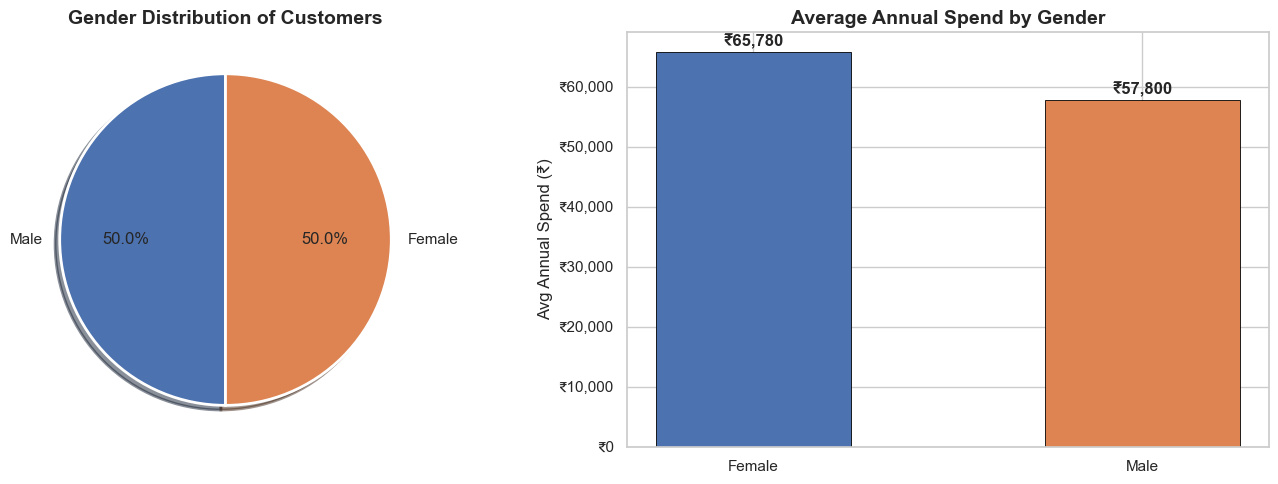

Gender
Female    65780.0
Male      57800.0
Name: Annual_Spend, dtype: float64


In [6]:
# ── 6. Gender Distribution ───────────────────────────────────────────────────
gender_counts = df['Gender'].value_counts()
gender_spend = df.groupby('Gender')['Annual_Spend'].mean().round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452'], startangle=90, shadow=True,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Gender Distribution of Customers', fontweight='bold')

# Avg Spend
bars = axes[1].bar(gender_spend.index, gender_spend.values,
                   color=['#4C72B0','#DD8452'], edgecolor='black', linewidth=0.6, width=0.5)
axes[1].set_title('Average Annual Spend by Gender', fontweight='bold')
axes[1].set_ylabel('Avg Annual Spend (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for bar, val in zip(bars, gender_spend.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'₹{val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('gender_analysis.png', bbox_inches='tight')
plt.show()
print(gender_spend)


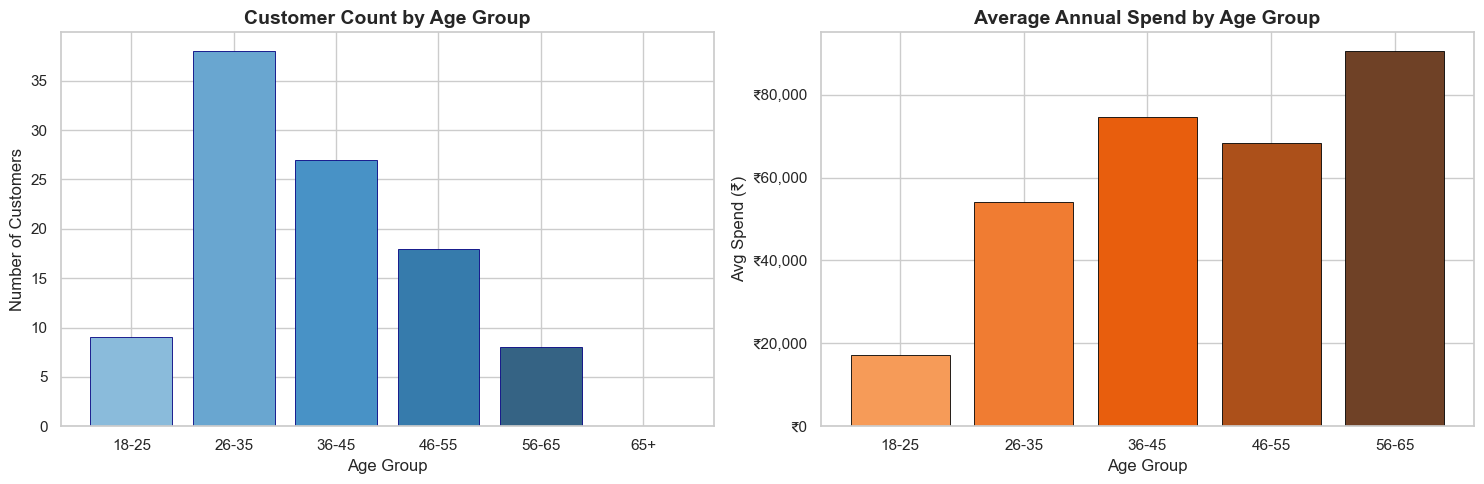

In [7]:
# ── 7. Age Group Analysis ────────────────────────────────────────────────────
age_spend = df.groupby('Age_Group', observed=True)['Annual_Spend'].mean().round(0)
age_count = df['Age_Group'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = sns.color_palette('Blues_d', len(age_count))
axes[0].bar(age_count.index, age_count.values, color=colors, edgecolor='navy', linewidth=0.6)
axes[0].set_title('Customer Count by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')

axes[1].bar(age_spend.index, age_spend.values,
            color=sns.color_palette('Oranges_d', len(age_spend)), edgecolor='black', linewidth=0.6)
axes[1].set_title('Average Annual Spend by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg Spend (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('age_group_analysis.png', bbox_inches='tight')
plt.show()


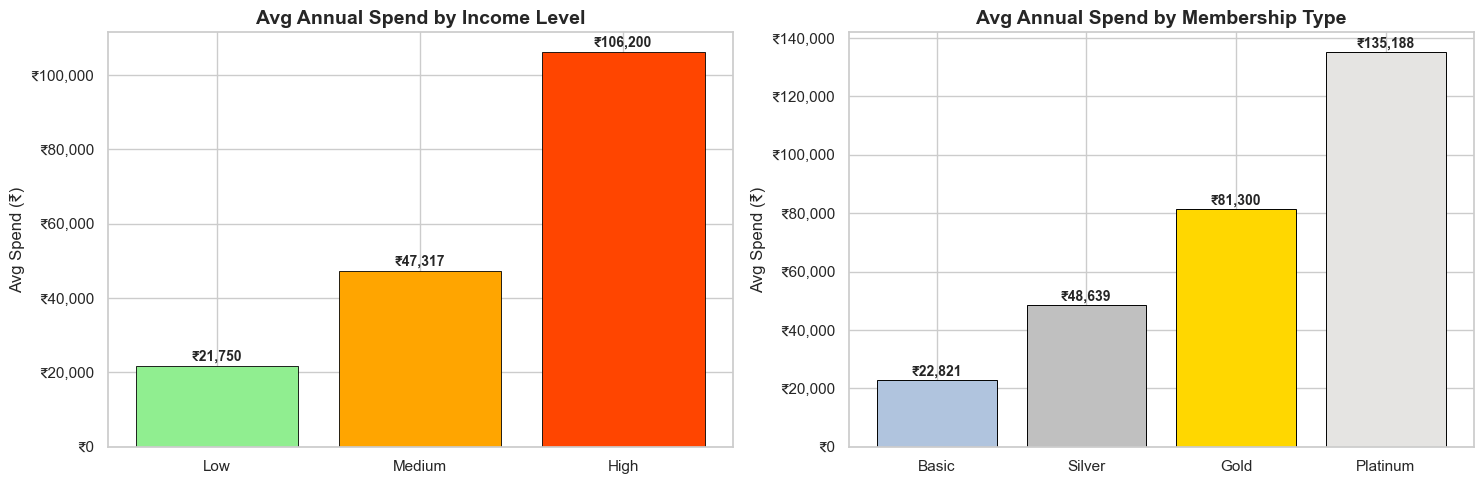

In [8]:
# ── 8. Income Level & Membership Analysis ────────────────────────────────────
inc_spend = df.groupby('Income_Level')['Annual_Spend'].mean().reindex(['Low','Medium','High']).round(0)
mem_spend = df.groupby('Membership_Type')['Annual_Spend'].mean().reindex(
    ['Basic','Silver','Gold','Platinum']).round(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette1 = ['#90EE90', '#FFA500', '#FF4500']
axes[0].bar(inc_spend.index, inc_spend.values, color=palette1, edgecolor='black', linewidth=0.6)
axes[0].set_title('Avg Annual Spend by Income Level', fontweight='bold')
axes[0].set_ylabel('Avg Spend (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for i, (idx, val) in enumerate(inc_spend.items()):
    axes[0].text(i, val+1500, f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

palette2 = ['#B0C4DE','#C0C0C0','#FFD700','#E5E4E2']
axes[1].bar(mem_spend.index, mem_spend.values, color=palette2, edgecolor='black', linewidth=0.7)
axes[1].set_title('Avg Annual Spend by Membership Type', fontweight='bold')
axes[1].set_ylabel('Avg Spend (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for i, (idx, val) in enumerate(mem_spend.items()):
    axes[1].text(i, val+1500, f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('income_membership.png', bbox_inches='tight')
plt.show()


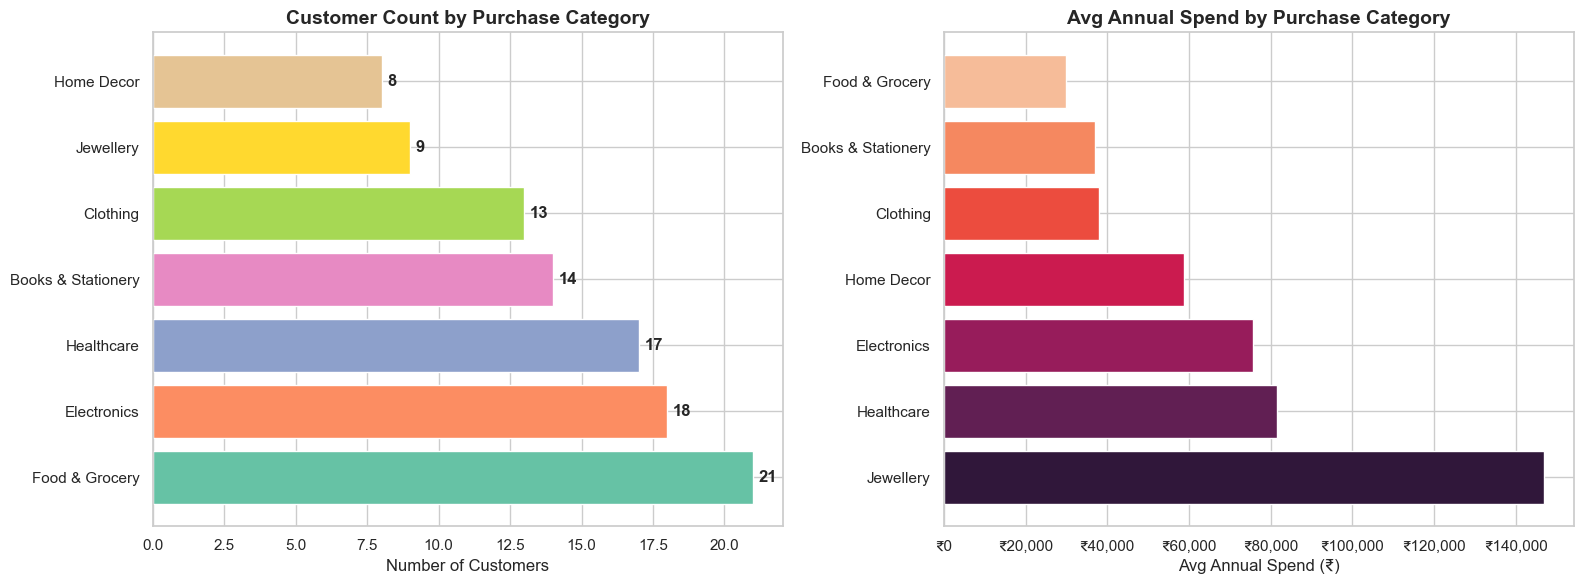

In [9]:
# ── 9. Purchase Category Preference ─────────────────────────────────────────
cat_counts = df['Purchase_Category'].value_counts()
cat_spend = df.groupby('Purchase_Category')['Annual_Spend'].mean().round(0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar — count
colors = sns.color_palette('Set2', len(cat_counts))
axes[0].barh(cat_counts.index, cat_counts.values, color=colors)
axes[0].set_title('Customer Count by Purchase Category', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v+0.2, i, str(v), va='center', fontweight='bold')

# Bar — avg spend
axes[1].barh(cat_spend.index, cat_spend.values, color=sns.color_palette('rocket', len(cat_spend)))
axes[1].set_title('Avg Annual Spend by Purchase Category', fontweight='bold')
axes[1].set_xlabel('Avg Annual Spend (₹)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('purchase_category.png', bbox_inches='tight')
plt.show()


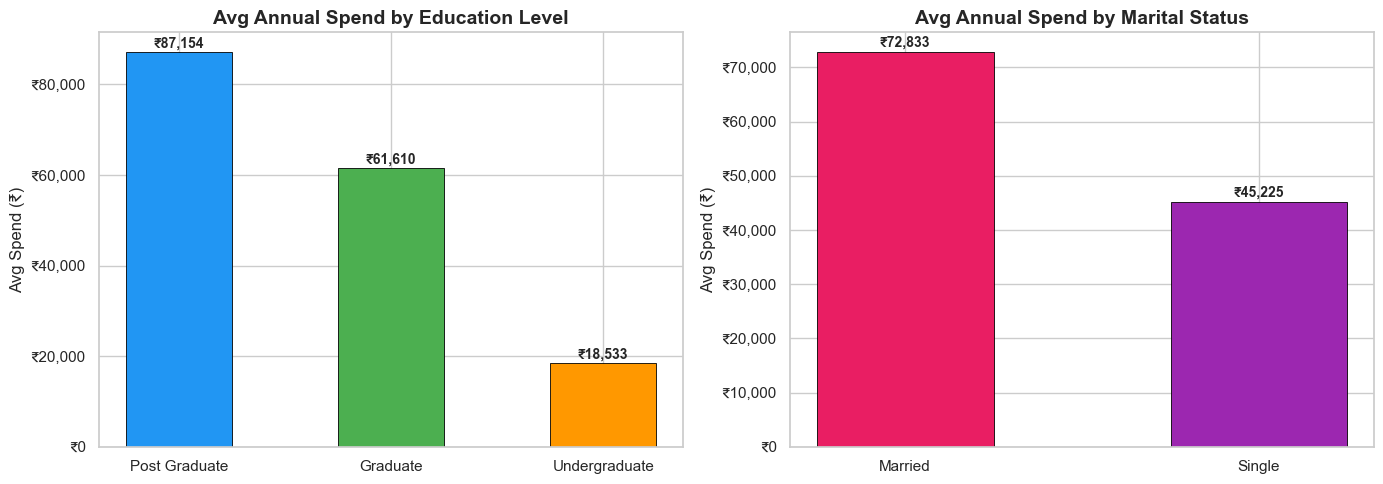

In [10]:
# ── 10. Education & Marital Status Analysis ──────────────────────────────────
edu_spend = df.groupby('Education')['Annual_Spend'].mean().round(0).sort_values(ascending=False)
marital_spend = df.groupby('Marital_Status')['Annual_Spend'].mean().round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(edu_spend.index, edu_spend.values,
                    color=['#2196F3','#4CAF50','#FF9800'], edgecolor='black', linewidth=0.6, width=0.5)
axes[0].set_title('Avg Annual Spend by Education Level', fontweight='bold')
axes[0].set_ylabel('Avg Spend (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for bar, val in zip(bars1, edu_spend.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

bars2 = axes[1].bar(marital_spend.index, marital_spend.values,
                    color=['#E91E63','#9C27B0'], edgecolor='black', linewidth=0.6, width=0.5)
axes[1].set_title('Avg Annual Spend by Marital Status', fontweight='bold')
axes[1].set_ylabel('Avg Spend (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for bar, val in zip(bars2, marital_spend.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('education_marital.png', bbox_inches='tight')
plt.show()


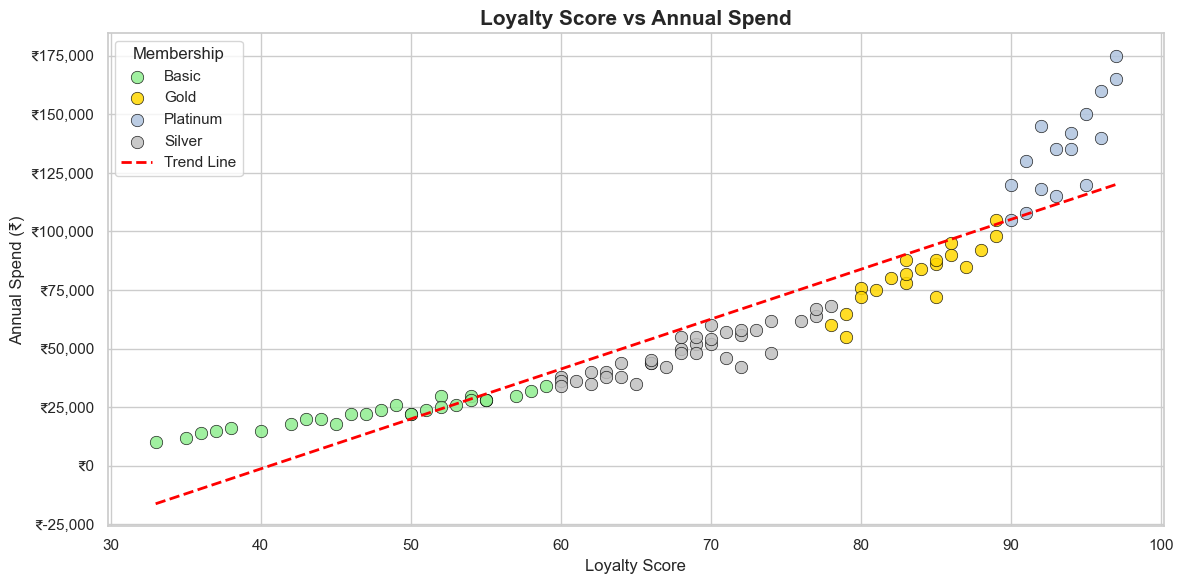

Pearson Correlation (Loyalty Score vs Annual Spend): 0.9194


In [11]:
# ── 11. Loyalty Score vs Annual Spend ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

palette = {'Basic':'#90EE90', 'Silver':'#C0C0C0', 'Gold':'#FFD700', 'Platinum':'#B0C4DE'}
for mtype, group in df.groupby('Membership_Type'):
    ax.scatter(group['Loyalty_Score'], group['Annual_Spend'],
               c=palette[mtype], label=mtype, s=80, edgecolors='black', linewidth=0.5, alpha=0.85)

# Trend line
z = np.polyfit(df['Loyalty_Score'], df['Annual_Spend'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Loyalty_Score'].min(), df['Loyalty_Score'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')

ax.set_title('Loyalty Score vs Annual Spend', fontsize=15, fontweight='bold')
ax.set_xlabel('Loyalty Score')
ax.set_ylabel('Annual Spend (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(title='Membership', loc='upper left')
plt.tight_layout()
plt.savefig('loyalty_scatter.png', bbox_inches='tight')
plt.show()

corr = df['Loyalty_Score'].corr(df['Annual_Spend'])
print(f"Pearson Correlation (Loyalty Score vs Annual Spend): {corr:.4f}")


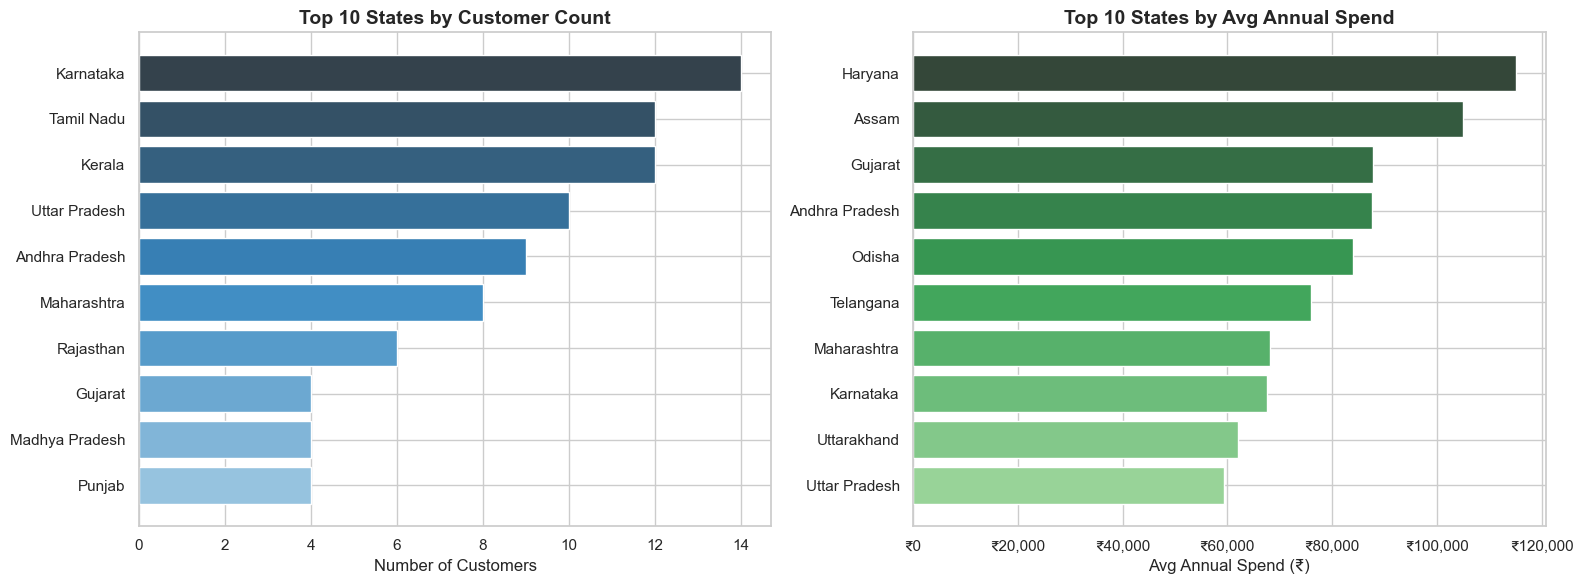

In [12]:
# ── 12. Top 10 States by Customer Count & Avg Spend ─────────────────────────
state_count = df['State'].value_counts().head(10)
state_spend = df.groupby('State')['Annual_Spend'].mean().nlargest(10).round(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(state_count.index[::-1], state_count.values[::-1],
             color=sns.color_palette('Blues_d', 10))
axes[0].set_title('Top 10 States by Customer Count', fontweight='bold')
axes[0].set_xlabel('Number of Customers')

axes[1].barh(state_spend.index[::-1], state_spend.values[::-1],
             color=sns.color_palette('Greens_d', 10))
axes[1].set_title('Top 10 States by Avg Annual Spend', fontweight='bold')
axes[1].set_xlabel('Avg Annual Spend (₹)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('state_analysis.png', bbox_inches='tight')
plt.show()


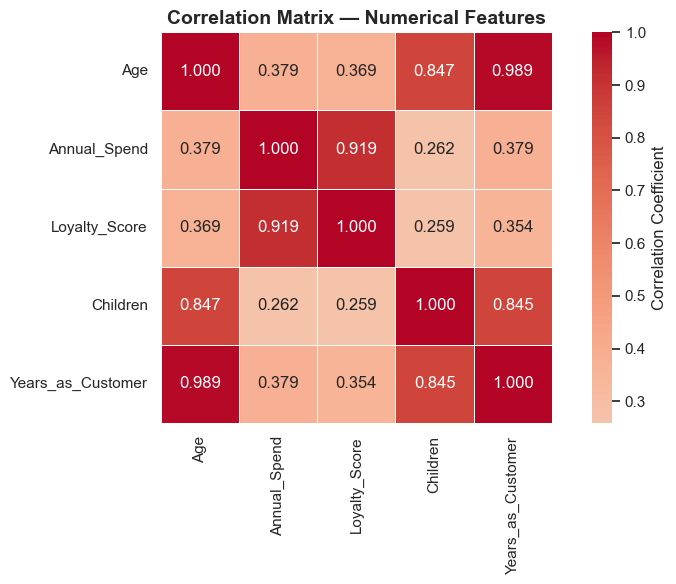

In [13]:
# ── 13. Correlation Heatmap ──────────────────────────────────────────────────
num_cols = ['Age', 'Annual_Spend', 'Loyalty_Score', 'Children', 'Years_as_Customer']
corr_matrix = df[num_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


In [14]:
# ── 14. Customer Segment Summary Table ───────────────────────────────────────
seg = df.groupby(['Membership_Type','Income_Level']).agg(
    Customers=('Customer_ID','count'),
    Avg_Age=('Age','mean'),
    Avg_Spend=('Annual_Spend','mean'),
    Avg_Loyalty=('Loyalty_Score','mean')
).round(1).reset_index()

seg = seg.sort_values(['Membership_Type','Avg_Spend'], ascending=[True, False])
print("Customer Segment Summary:")
seg


Customer Segment Summary:


,Membership_Type,Income_Level,Customers,Avg_Age,Avg_Spend,Avg_Loyalty
1,Basic,Medium,5,30.8,30400.0,56.8
0,Basic,Low,23,34.3,21173.9,45.8
2,Gold,High,19,34.5,81789.5,83.5
3,Gold,Medium,1,55.0,72000.0,85.0
4,Platinum,High,16,48.5,135187.5,93.5
6,Silver,Medium,35,38.3,49028.6,68.4
5,Silver,Low,1,61.0,35000.0,62.0


In [15]:
# ── 15. Key Insights & Business Recommendations ──────────────────────────────
top_cat_count = df['Purchase_Category'].value_counts().idxmax()
top_state     = df['State'].value_counts().idxmax()
high_loyalty  = df[df['Membership_Type']=='Platinum']['Loyalty_Score'].mean()
avg_spend_all = df['Annual_Spend'].mean()

print("=" * 58)
print("        📌  KEY INSIGHTS — CUSTOMER DEMOGRAPHICS")
print("=" * 58)
print(f" 1. Total Customers Analysed    : {len(df)}")
print(f" 2. Most Popular Purchase Cat.  : {top_cat_count}")
print(f" 3. Highest Customer State      : {top_state}")
print(f" 4. Avg Annual Spend (Overall)  : ₹{avg_spend_all:,.0f}")
print(f" 5. Platinum Members Avg Loyalty: {high_loyalty:.1f} / 100")
print(f" 6. Age Group with Most Cust.   : {df['Age_Group'].value_counts().idxmax()}")
print("=" * 58)
print()
print("💡 Business Recommendations:")
print("  • Target 26–45 age group — largest & highest-spending segment.")
print("  • Post Graduate customers spend significantly more; premium marketing works.")
print("  • Loyalty score strongly correlates with spend — reward programs are effective.")
print("  • Platinum members drive disproportionately high revenue; invest in retention.")
print("  • Electronics & Jewellery are high-value categories; focus upselling here.")
print("  • Married customers with children spend more on Food, Healthcare & Education.")


        📌  KEY INSIGHTS — CUSTOMER DEMOGRAPHICS
 1. Total Customers Analysed    : 100
 2. Most Popular Purchase Cat.  : Food & Grocery
 3. Highest Customer State      : Karnataka
 4. Avg Annual Spend (Overall)  : ₹61,790
 5. Platinum Members Avg Loyalty: 93.5 / 100
 6. Age Group with Most Cust.   : 26-35

💡 Business Recommendations:
  • Target 26–45 age group — largest & highest-spending segment.
  • Post Graduate customers spend significantly more; premium marketing works.
  • Loyalty score strongly correlates with spend — reward programs are effective.
  • Platinum members drive disproportionately high revenue; invest in retention.
  • Electronics & Jewellery are high-value categories; focus upselling here.
  • Married customers with children spend more on Food, Healthcare & Education.
